# 03 — DL 모형 (1D-CNN / TCN)

| 모델   | seq_len | 비고                    |
|--------|---------|-------------------------|
| 1DCNN  | 30      | short receptive field   |
| TCN    | 60      | dilated causal conv     |

# **산출물** (ML과 동일 구조):
- `results/dl_results_{tier}.csv`
- `results/dl_tuned_params.csv`
- `results/best_models/{model}/{regime}_{country}_{tier}.pkl`
- `log/{model}/log_{model}_{regime}_{country}.csv`

## 0. 환경 설정

In [1]:
import os, sys
from pathlib import Path

# Colab 마운트
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    os.environ['FINTEL_PROJECT_ROOT'] = (
        '/content/drive/MyDrive/FINTEL/Project'
    )
except ImportError:
    pass

PROJECT_ROOT = Path(os.environ.get('FINTEL_PROJECT_ROOT', Path.cwd().parent))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive


In [2]:
# 패키지 설치 (Colab 최초 1회)
import subprocess
subprocess.run(
    ['pip', 'install', '-q', '-r',
     str(PROJECT_ROOT / 'requirements.txt')],
    check=True,
)

import time, warnings, random
from itertools import product
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

warnings.filterwarnings('ignore')

# Seed 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 프로젝트 모듈
from src import config
from src.data_loader import load_dataset
from src.preprocess import get_feature_list
from src.models import (
    DL_MODEL_REGISTRY, DL_SEQ_LEN,
    ALL_DL_MODEL_NAMES, make_dl_model,
)
from src.eval import (
    evaluate, iter_phases,
    tune_dl_model, run_dl_static, run_dl_expanding,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'Models  : {ALL_DL_MODEL_NAMES}')
print(f'Seq len : {DL_SEQ_LEN}')

Device  : cuda
Models  : ['1DCNN', 'TCN']
Seq len : {'1DCNN': 30, 'TCN': 60}


## 1. 그리드 정의

In [3]:
TIERS       = ['core', 'momentum', 'extended']
PROTOCOLS   = ['static', 'expanding']
REFIT_EVERY = 5
DL_N_TRIALS = 10

# 학습 설정
TRAIN_CFG = dict(max_epochs=80, patience=8, batch_size=64)
# expanding refit: warm-start + 느슨한 refit으로 시간 절약
EXPAND_CFG = dict(max_epochs=10, patience=3, batch_size=64, warm_start=True)

# 디버그용 override (None = 정상 실행)
N_TRIALS_OVERRIDE: int | None = None

print(f'regimes  : {config.REGIMES}')
print(f'countries: {config.COUNTRIES}')
print(f'tiers    : {TIERS}')
print(f'protocols: {PROTOCOLS}')
print(f'n_trials : {DL_N_TRIALS}')

regimes  : ['normal', '911', 'gfc', 'covid']
countries: ['US', 'KR', 'JP']
tiers    : ['core', 'momentum', 'extended']
protocols: ['static', 'expanding']
n_trials : 10


## 2. 데이터 로딩 헬퍼

In [4]:
def load_split_3way(regime: str, country: str):
    """CSV split 컬럼 기반 3분할 — ML(02)과 동일."""
    df = load_dataset(regime, country)
    df = df.dropna(subset=['RV_target', 'RV_d', 'RV_w', 'RV_m', 'log_return'])
    return (
        df[df['split'] == 'train'].copy(),
        df[df['split'] == 'valid'].copy(),
        df[df['split'] == 'test'].copy(),
    )

# Sanity check
tr, va, te = load_split_3way('normal', 'US')
print(f'normal/US  train={len(tr)} valid={len(va)} test={len(te)}')
print(f'TCN 최소 필요 길이: seq_len={DL_SEQ_LEN["TCN"]} → train 충분: {len(tr) > DL_SEQ_LEN["TCN"]}')


normal/US  train=2982 valid=506 test=1502
TCN 최소 필요 길이: seq_len=60 → train 충분: True


## 3. 그리드 실행

### 각 (regime × country × tier × model) 조합:
1. Optuna 튜닝 (train + valid → best_params)
2. static + expanding 프로토콜로 test 예측
3. phase별 평가 → 결과 행 누적

### **예상 소요 시간** (T4 기준, warm-start expanding):
- 튜닝: 2 model × 12 × 3 tier × 10 trials ≈ ~15 ~20분
- static + expanding: 추가 ~10 ~20분
- **총 25~40분 예상**

In [5]:
results     = []
preds_cache = {}   # (model, regime, country, tier, protocol) → pd.Series
tuned_cache = {}   # (model, regime, country, tier) → (best_params, best_qlike)

# best model 저장 디렉토리
BEST_MODELS_DIR = config.RESULTS_DIR / 'best_models'
for model_name in ALL_DL_MODEL_NAMES:
    (BEST_MODELS_DIR / model_name).mkdir(parents=True, exist_ok=True)

t_total = time.time()

for regime, country in product(config.REGIMES, config.COUNTRIES):
    train, valid, test = load_split_3way(regime, country)
    combined = pd.concat([train, valid])
    print(f'\n[{regime}/{country}] '
          f'train={len(train)} valid={len(valid)} '
          f'combined={len(combined)} test={len(test)}')

    for tier in TIERS:
        feats = get_feature_list(train, country, tier)

        for model_name in ALL_DL_MODEL_NAMES:
            n_trials   = N_TRIALS_OVERRIDE or DL_N_TRIALS
            case_start = time.time()

            # 1) Optuna 튜닝
            t0 = time.time()
            best_params, best_qlike = tune_dl_model(
                model_name, train, valid, feats,
                n_trials=n_trials, seed=SEED, device=DEVICE,
                **TRAIN_CFG,
            )
            tune_sec = time.time() - t0
            tuned_cache[(model_name, regime, country, tier)] = (best_params, best_qlike)

            # 2) static
            t0 = time.time()
            y_pred_static, final_model = run_dl_static(
                model_name, combined, test, feats, best_params,
                seed=SEED, device=DEVICE, **TRAIN_CFG,
            )
            y_pred_static = y_pred_static.reindex(test.index)
            static_sec = time.time() - t0

            static_mask = y_pred_static.notna()
            static_metrics = evaluate(
                test.loc[static_mask, 'RV_target'],
                y_pred_static[static_mask],
            )

            preds_cache[(model_name, regime, country, tier, 'static')] = y_pred_static

            for phase_name, mask, _color in iter_phases(test, regime):
                if mask.sum() == 0:
                    continue
                valid_mask = mask & y_pred_static.notna()
                if valid_mask.sum() == 0:
                    continue
                metrics = evaluate(
                    test.loc[valid_mask, 'RV_target'],
                    y_pred_static[valid_mask],
                )
                results.append({
                    'model'         : model_name,
                    'regime'        : regime,
                    'country'       : country,
                    'feature_set'   : tier,
                    'protocol'      : 'static',
                    'phase'         : phase_name,
                    **metrics,
                    'best_val_qlike': best_qlike,
                    'n_features'    : len(feats),
                    'seq_len'       : DL_SEQ_LEN[model_name],
                })

            # best model 저장 (static만)
            pkl_path = (
                BEST_MODELS_DIR / model_name
                / f'{regime}_{country}_{tier}.pkl'
            )
            joblib.dump({
                'model_state'   : final_model.cpu().state_dict(),
                'model_name'    : model_name,
                'feature_cols'  : feats,
                'best_params'   : best_params,
                'best_val_qlike': best_qlike,
                'regime'        : regime,
                'country'       : country,
                'tier'          : tier,
                'seq_len'       : DL_SEQ_LEN[model_name],
                'fit_data'      : 'train+valid',
            }, pkl_path)

            # 3) expanding
            t0 = time.time()
            y_pred_expanding = run_dl_expanding(
                model_name, combined, test, feats, best_params,
                refit_every=REFIT_EVERY,
                seed=SEED, device=DEVICE,
                **EXPAND_CFG,
            )
            expanding_sec = time.time() - t0

            expanding_mask = y_pred_expanding.notna()
            expanding_metrics = evaluate(
                test.loc[expanding_mask, 'RV_target'],
                y_pred_expanding[expanding_mask],
            )

            preds_cache[(model_name, regime, country, tier, 'expanding')] = y_pred_expanding

            for phase_name, mask, _color in iter_phases(test, regime):
                if mask.sum() == 0:
                    continue
                valid_mask = mask & y_pred_expanding.notna()
                if valid_mask.sum() == 0:
                    continue
                metrics = evaluate(
                    test.loc[valid_mask, 'RV_target'],
                    y_pred_expanding[valid_mask],
                )
                results.append({
                    'model'         : model_name,
                    'regime'        : regime,
                    'country'       : country,
                    'feature_set'   : tier,
                    'protocol'      : 'expanding',
                    'phase'         : phase_name,
                    **metrics,
                    'best_val_qlike': best_qlike,
                    'n_features'    : len(feats),
                    'seq_len'       : DL_SEQ_LEN[model_name],
                })

            total_sec = time.time() - case_start

            print(f'Case = {regime}/{country}/{tier}/{model_name}')
            print(f'tune_sec = {tune_sec:.1f}')
            print(f'static_sec = {static_sec:.1f}')
            print(f'expanding_sec = {expanding_sec:.1f}')
            print(f'total_sec = {total_sec:.1f}')
            print(f'best_val_qlike = {best_qlike:.4f}')
            print(f'best_params = {best_params}')
            print(f'static metrics = {static_metrics}')
            print(f'expanding metrics = {expanding_metrics}')
            print('-' * 150)

results_df = pd.DataFrame(results)
print(f'\n총 행: {len(results_df)}  '
      f'/ 총 소요: {(time.time() - t_total) / 60:.1f}분')
print(f'best models 저장 위치: {BEST_MODELS_DIR}')


[normal/US] train=2982 valid=506 combined=3488 test=1502
Case = normal/US/core/1DCNN
tune_sec = 87.6
static_sec = 7.3
expanding_sec = 399.8
total_sec = 495.4
best_val_qlike = 0.5320
best_params = {'lr': 0.008706020878304856, 'dropout': 0.2497327922401265, 'hidden_dim': 32, 'num_filters': 64, 'kernel_size': 5}
static metrics = {'RMSE': 0.28865064674863034, 'MAE': 0.2047581949314136, 'QLIKE': 0.08089529713669986, 'RMSE_CV': 0.49330785292285717}
expanding metrics = {'RMSE': 0.28139343492565017, 'MAE': 0.19022200574630085, 'QLIKE': 0.07626581987538475, 'RMSE_CV': 0.4809490812151656}
------------------------------------------------------------------------------------------------------------------------------------------------------
Case = normal/US/core/TCN
tune_sec = 79.7
static_sec = 6.2
expanding_sec = 651.0
total_sec = 737.5
best_val_qlike = 0.5382
best_params = {'lr': 0.0026070247583707684, 'dropout': 0.006175348288740734, 'hidden_dim': 32, 'num_layers': 2, 'kernel_size': 5}
static me

## 4. 결과 저장 — tier별 분리 CSV

In [6]:
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

saved_files = []
for tier in TIERS:
    df_tier = results_df[results_df['feature_set'] == tier].copy()
    out     = config.RESULTS_DIR / f'dl_results_{tier}.csv'
    df_tier.to_csv(out, index=False)
    saved_files.append((out, len(df_tier)))
    print(f'  saved → {out.name}  ({len(df_tier)}행)')

total_rows = sum(n for _, n in saved_files)
print(f'\n총합: {total_rows}행')
print('예상: 2 model × 4 regime × 3 country × 2 protocol × phase수')
results_df.head()

  saved → dl_results_core.csv  (144행)
  saved → dl_results_momentum.csv  (144행)
  saved → dl_results_extended.csv  (144행)

총합: 432행
예상: 2 model × 4 regime × 3 country × 2 protocol × phase수


,model,regime,country,feature_set,protocol,phase,RMSE,MAE,QLIKE,RMSE_CV,best_val_qlike,n_features,seq_len
0,1DCNN,normal,US,core,static,Full Test,0.288651,0.204758,0.080895,0.493308,0.532018,10,30
1,1DCNN,normal,US,core,expanding,Full Test,0.281393,0.190222,0.076266,0.480949,0.532018,10,30
2,TCN,normal,US,core,static,Full Test,0.307790,0.210281,0.086538,0.526017,0.538165,10,60
3,TCN,normal,US,core,expanding,Full Test,0.370365,0.251391,0.127585,0.633016,0.538165,10,60
4,1DCNN,normal,US,momentum,static,Full Test,0.277434,0.194036,0.075298,0.474139,0.530439,14,30



## 5. 예측 로그 저장

- `log/{model}/log_{model}_{regime}_{country}.csv`
- 컬럼: date, feature_set, protocol, RV_target, RV_pred


In [7]:
LOG_DIR = PROJECT_ROOT / 'log'
LOG_DIR.mkdir(parents=True, exist_ok=True)
for model_name in ALL_DL_MODEL_NAMES:
    (LOG_DIR / model_name).mkdir(parents=True, exist_ok=True)

# (model, regime, country) 단위로 그룹핑
groups: dict = defaultdict(list)
for (model_name, regime, country, tier, protocol), y_pred in preds_cache.items():
    groups[(model_name, regime, country)].append((tier, protocol, y_pred))

saved_logs = []
for (model_name, regime, country), entries in groups.items():
    _, _, test = load_split_3way(regime, country)
    test_idx   = test.index

    rows = []
    for tier, protocol, y_pred in entries:
        rows.append(pd.DataFrame({
            'date'       : test_idx,
            'feature_set': tier,
            'protocol'   : protocol,
            'RV_target'  : test['RV_target'].values,
            'RV_pred'    : y_pred.reindex(test_idx).values,
        }))

    out_df   = pd.concat(rows, ignore_index=True)
    out_path = (
        LOG_DIR / model_name
        / f'log_{model_name}_{regime}_{country}.csv'
    )
    out_df.to_csv(out_path, index=False)
    saved_logs.append(out_path)

print(f'saved → {len(saved_logs)}개 CSV')
print(f'예상: 2 model × 12 (regime × country) = 24 파일')
print(f'예시: {saved_logs[0].relative_to(PROJECT_ROOT)}')

saved → 24개 CSV
예상: 2 model × 12 (regime × country) = 24 파일
예시: log/1DCNN/log_1DCNN_normal_US.csv


## 6. 시각화 — 위기 phase 음영

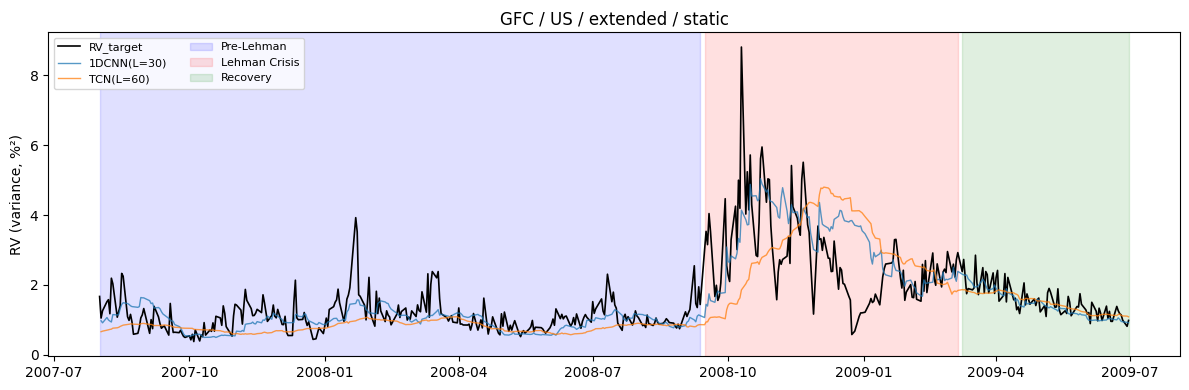

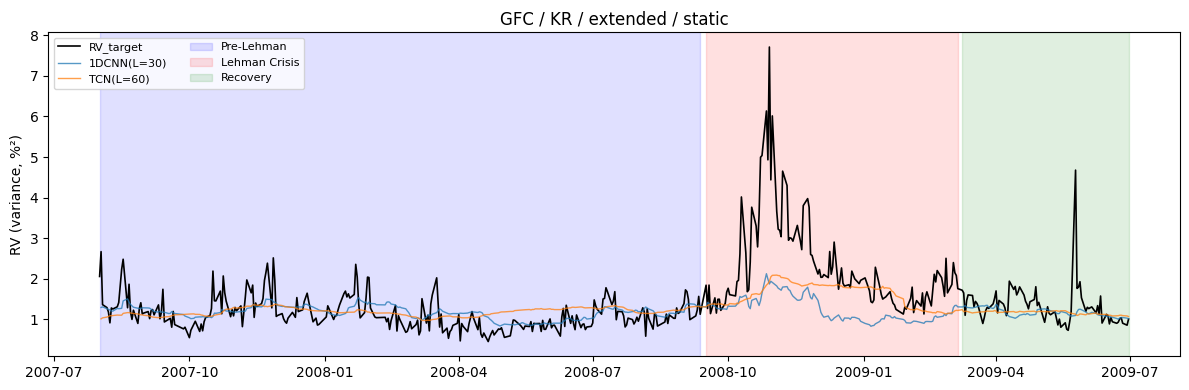

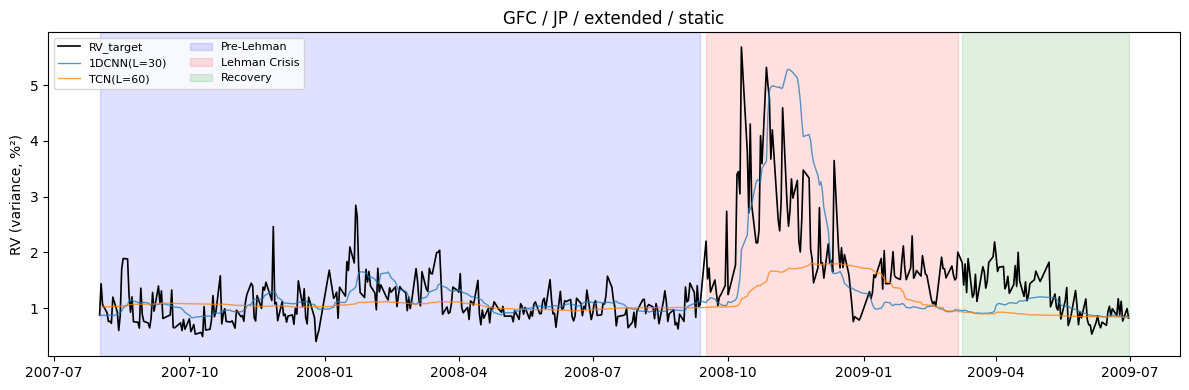

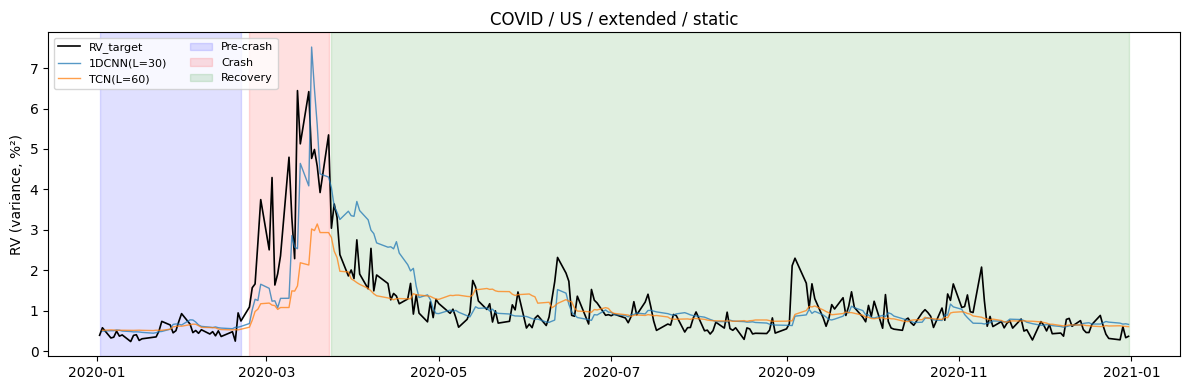

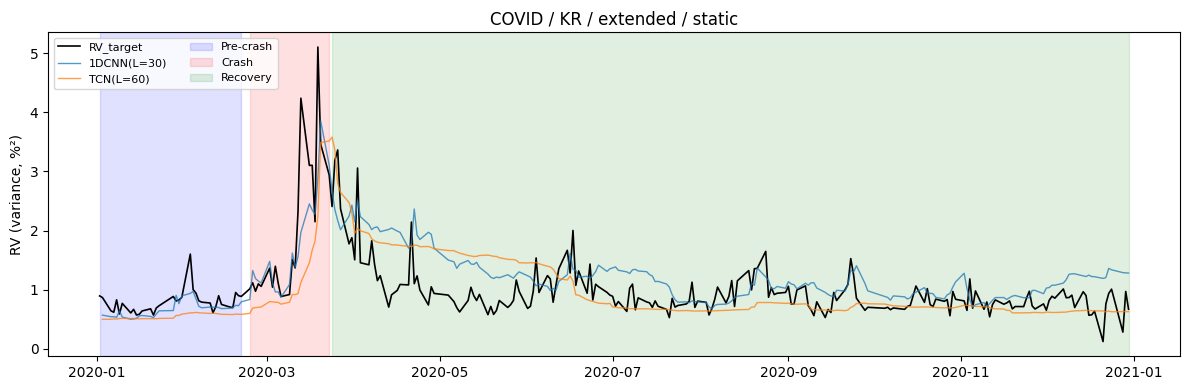

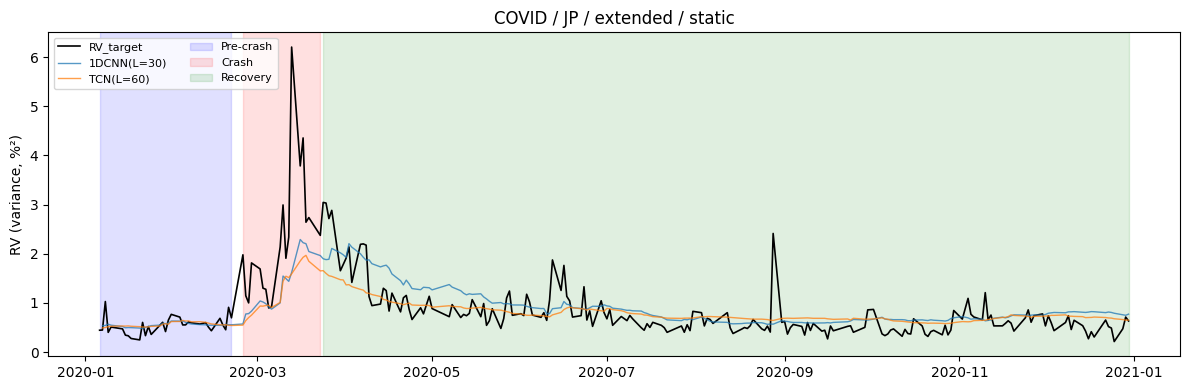

In [8]:
def plot_dl_predictions(
    regime  : str,
    country : str,
    tier    : str = 'extended',
    protocol: str = 'static',
) -> None:
    _, _, test = load_split_3way(regime, country)
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(test.index, test['RV_target'],
            color='black', lw=1.2, label='RV_target')

    for model_name in ALL_DL_MODEL_NAMES:
        key = (model_name, regime, country, tier, protocol)
        if key in preds_cache:
            ax.plot(
                test.index, preds_cache[key], lw=1, alpha=0.75,
                label=f'{model_name}(L={DL_SEQ_LEN[model_name]})',
            )

    for name, mask, color in iter_phases(test, regime):
        if name == 'Full Test' or color is None:
            continue
        idx = test.index[mask]
        if len(idx) > 0:
            ax.axvspan(idx.min(), idx.max(),
                       color=color, alpha=0.12, label=name)

    ax.set_title(f'{regime.upper()} / {country} / {tier} / {protocol}')
    ax.set_ylabel('RV (variance, %²)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

for regime in ['gfc', 'covid']:
    for country in config.COUNTRIES:
        plot_dl_predictions(regime, country, 'extended', 'static')

## 7. Tier 효과 분석 — Core → Momentum → Extended

In [9]:
tier_effect = (
    results_df[results_df['phase'] == 'Full Test']
    .groupby(['feature_set', 'model'])['QLIKE']
    .mean()
    .unstack('feature_set')
    .reindex(columns=TIERS)
    .round(4)
)
tier_effect['Δ Core→Momentum']     = (
    tier_effect['momentum'] - tier_effect['core']
).round(4)
tier_effect['Δ Momentum→Extended'] = (
    tier_effect['extended'] - tier_effect['momentum']
).round(4)
tier_effect

feature_set,core,momentum,extended,Δ Core→Momentum,Δ Momentum→Extended
model,,,,,
1DCNN,0.0605,0.0617,0.0763,0.0012,0.0146
TCN,0.0811,0.0865,0.1009,0.0054,0.0144


## 8. Tuned hyperparameters 저장

In [10]:
tuned_rows = []
for (model, regime, country, tier), (params, qlike) in tuned_cache.items():
    row = {
        'model'         : model,
        'regime'        : regime,
        'country'       : country,
        'feature_set'   : tier,
        'best_val_qlike': qlike,
        'seq_len'       : DL_SEQ_LEN[model],
    }
    row.update({f'param_{k}': v for k, v in params.items()})
    tuned_rows.append(row)

tuned_df = pd.DataFrame(tuned_rows)
tuned_df.to_csv(config.RESULTS_DIR / 'dl_tuned_params.csv', index=False)
print(f'saved → dl_tuned_params.csv ({len(tuned_df)}행)')
print(f'예상: 2 model × 4 regime × 3 country × 3 tier = 72행')
tuned_df.head()

saved → dl_tuned_params.csv (72행)
예상: 2 model × 4 regime × 3 country × 3 tier = 72행


,model,regime,country,feature_set,best_val_qlike,seq_len,param_lr,param_dropout,param_hidden_dim,param_num_filters,param_kernel_size,param_num_layers
0,1DCNN,normal,US,core,0.532018,30,0.008706,0.249733,32,64.0,5,NaN
1,TCN,normal,US,core,0.538165,60,0.002607,0.006175,32,NaN,5,2.0
2,1DCNN,normal,US,momentum,0.530439,30,0.008706,0.249733,32,64.0,5,NaN
3,TCN,normal,US,momentum,0.536608,60,0.002607,0.006175,32,NaN,5,2.0
4,1DCNN,normal,US,extended,0.538024,30,0.007903,0.289690,32,32.0,7,NaN
